> TO DO

1. Inspect whether we can make use of some measure of sensitivity from totalistic CAs (and highlight how a general totalistic CA is different from the case we are studying here now).
2. Make a visual comparison of the jaggedness with some time evolution patterns
3. Find better names than 'jaggedness'. Possibilities: horizontal sensitivity vs. vertical sensitivity; density sensitivity vs. flip sensitivity; neighbourhood sensitivity vs identity sensitivity; peripheral reactivity vs. reflective reactivity.

# Define jaggedness

In this notebook we will present progressively better definitions of "jaggedness" (actual name pending).

This is a measure that allows us to predict the way in which a defect may spread through a network, based on the LLNA's local update rule and the the networks' degree distribution.

## General principles

In the context of LLNAs, introducing a single defect has two effects:
1. The node that changes state will obey a different update rule
2. The nodes in the changed node's neighbourhood will experience a change in their neighbourhood's state density

These changes can have a big effect or a small effect on the dynamics of the system.

## The naive definition

In [1]:
import torch as tc
import igraph as ig
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import rcParams

# Enable LaTeX and set Times New Roman as the font
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: Use LaTeX packages
})

from tqdm import tqdm

import sys, os
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(parent_dir)

from src.automata import LLNA
from src.simulation import *

%load_ext autoreload
%autoreload 2

In the first definition we only look at the effect of slightly modifying the local density. In particular we look at how many opportunities the LLNA has to change its output when a defect is introduced. We quantify this by counting the number of 'borders' in the diagram of the local update rule, dividing by the total possible number. Some examples are listed below:

In [6]:
def nbh_sensitivity(resolution, B_set, S_set):
    ### value between 0 and 1
    # make numpy array
    B_set = np.array(B_set)
    S_set = np.array(S_set)
    # turn interval index into bits
    B_set_bin = np.zeros(resolution, dtype=int)
    S_set_bin = np.zeros(resolution, dtype=int)
    if B_set.size: B_set_bin[B_set] = 1
    if S_set.size: S_set_bin[S_set] = 1
    # perform XOR with shifted arrays
    borders_B = np.logical_xor(B_set_bin[1:], B_set_bin[:-1]).sum()
    borders_S = np.logical_xor(S_set_bin[1:], S_set_bin[:-1]).sum()
    # return total number of edges
    return (borders_B + borders_S)/(resolution-1)/2

resolution = 3
born_if = [0,1]
survive_if = [0,1]
nbh_sensitivity(resolution, born_if, survive_if)

0.5

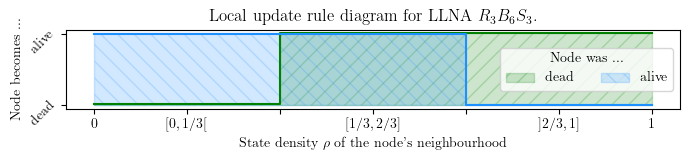

In [7]:
SAVEFIG=False

fig, ax = plt.subplots(1,1,figsize=(7,1.7))

resolution = 3
born_if = [1, 2]
survive_if = [0,1]
model = LLNA(resolution, x=born_if, y=survive_if, iso=True)
model.diagram(ax=ax)
j = nbh_sensitivity(resolution, born_if, survive_if)
borders = j * 2*(resolution-1)
ax.set_title(f"Local update rule diagram for LLNA {model.__str__(latex=True)}.")

fig.tight_layout()
if SAVEFIG:
    # Note: saving as PDF fails to show the hatches
    plt.savefig(f"update-rule-diagram_rule{model.__str__()}.png", dpi=600)

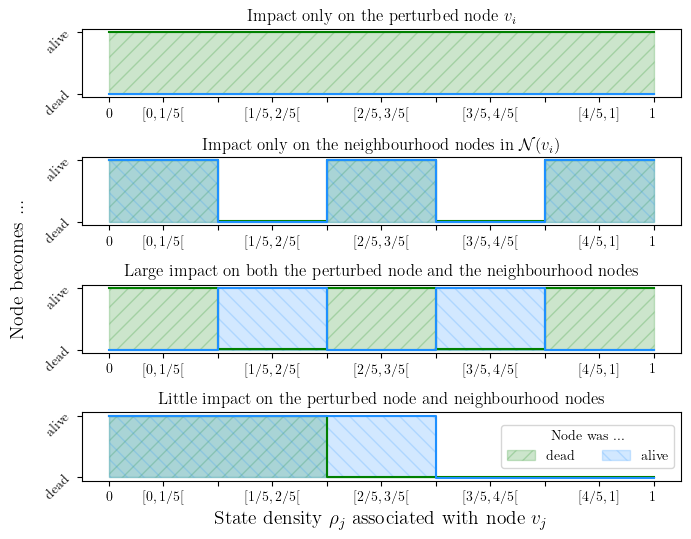

In [8]:
SAVEFIG=False

fig, axs = plt.subplots(4,1,figsize=(7, 5.5))

resolution = 5
born_if = [0, 1, 2, 3, 4]
survive_if = []
model = LLNA(resolution, x=born_if, y=survive_if)
model.diagram(ax=axs[0])
axs[0].set_title(fr"Impact only on the perturbed node $v_i$")
axs[0].set_xlabel(None)
axs[0].set_ylabel(None)
axs[0].get_legend().remove()

resolution = 5
born_if = [0, 2, 4]
survive_if = [0, 2, 4]
model = LLNA(resolution, x=born_if, y=survive_if)
model.diagram(ax=axs[1])
axs[1].set_title(r"Impact only on the neighbourhood nodes in $\mathcal{N}(v_i)$")
axs[1].set_xlabel(None)
axs[1].set_ylabel(None)
axs[1].get_legend().remove()

resolution = 5
born_if = [0, 2, 4]
survive_if = [1, 3]
model = LLNA(resolution, x=born_if, y=survive_if)
model.diagram(ax=axs[2])
axs[2].set_title(f"Large impact on both the perturbed node and the neighbourhood nodes")
axs[2].set_xlabel(None)
axs[2].set_ylabel(None)
axs[2].get_legend().remove()

resolution = 5
born_if = [0, 1]
survive_if = [0, 1, 2] 
model = LLNA(resolution, x=born_if, y=survive_if)
model.diagram(ax=axs[3])
axs[3].set_title(f"Little impact on the perturbed node and neighbourhood nodes")
axs[3].set_xlabel(fr"State density $\rho_j$ associated with node $v_j$", size=14)
axs[3].set_ylabel(None)

# fig.supxlabel(fr"State density $\rho_j$ associated with node $v_j$")
fig.supylabel(fr"Node becomes ...", size=14)
fig.tight_layout()

if SAVEFIG:
    # Note: saving as PDF fails to show the hatches
    plt.savefig(f"some-examples-of-obvious-diagrams.png", dpi=600)

Note:
1. We do not count the outer borders (those at $\rho = 0$ and $\rho = 1$) because they cannot be crossed.
2. The $B$ set has the same number of edges as the $B^\text{C}$ set, so the representation in the diagram does not matter.
3. There are always $2(R-1)$ possible borders.
4. There are more possibilities with an average number of borders than with a low or high number of borders.

## Add notion of changing the central node

If the central node is perturbed, the neighbourhood density is not altered, but the dynamical outcome may of course change as well. This is expressed by looking at some kind of XOR operation between the survive set and the born set. Again this value is normalised over the maximum (which is simply the resolution).

In [9]:
def id_sensitivity(resolution, B_set, S_set):
    # make numpy array
    B_set = np.array(B_set)
    S_set = np.array(S_set)
    # turn interval index into bits
    B_set_bin = np.zeros(resolution, dtype=int)
    S_set_bin = np.zeros(resolution, dtype=int)
    if B_set.size: B_set_bin[B_set] = 1
    if S_set.size: S_set_bin[S_set] = 1
    borders = np.logical_xor(B_set_bin, S_set_bin).sum()
    return borders / resolution

resolution = 3
born_if = [0,1,2]
survive_if = []
id_sensitivity(resolution, born_if, survive_if)

1.0

In this spirit, the LLNA that can maximally change the outcome is the one that is the most jagged, and for which the born set is the complement of the survive set, for example

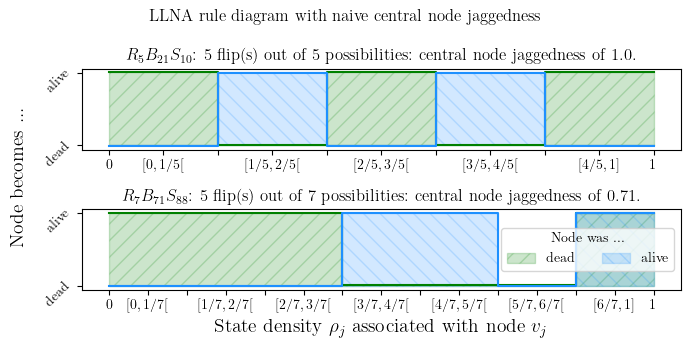

In [10]:
SAVEFIG=False

fig, axs = plt.subplots(2,1,figsize=(7, 3.5))

resolution = 5
born_if = [0, 2, 4]
survive_if = [1, 3]
model = LLNA(resolution, x=born_if, y=survive_if)
model.diagram(ax=axs[0])
j = id_sensitivity(resolution, born_if, survive_if)
flips = int(j*resolution)
axs[0].set_title(f"{model.__str__(latex=True)}: {flips} flip(s) out of {resolution} possibilities: central node jaggedness of {round(j,2)}.")
axs[0].get_legend().remove()
axs[0].set_xlabel(None)
axs[0].set_ylabel(None)

resolution = 7
born_if = [0, 1, 2, 6]
survive_if = [3, 4, 6]
model = LLNA(resolution, x=born_if, y=survive_if)
model.diagram(ax=axs[1])
j = id_sensitivity(resolution, born_if, survive_if)
flips = int(j*resolution)
axs[1].set_title(f"{model.__str__(latex=True)}: {flips} flip(s) out of {resolution} possibilities: central node jaggedness of {round(j,2)}.")
axs[1].set_xlabel(fr"State density $\rho_j$ associated with node $v_j$", size=14)
axs[1].set_ylabel(None)

fig.suptitle("LLNA rule diagram with naive central node jaggedness")
fig.supylabel("Node becomes ...", size=14)
fig.tight_layout()

It is not a priori clear how we should balance these two effects: the effect of changing the neighbourhood density, and the effect of changing the central node state. Some observations include:
1. Changing the state of the central node will always have the same effect; it is not depedent on the density of the local neighbourhood (and hence not dependent on the node degree)
2. LLNAs for which the 'central node jaggedness' is low and the 'naive jaggedness' is high, will generally not be very affected by introducing a defect. It is not clear, however, how important these definitions are compared to one another.
3. For isomorphic LLNAs, values from both jaggedness definitions are unchanged under an isomorphism

Also, a single jaggedness value is associated with a varying number of LLNAs. That is to say ...

_naive jaggedness definition_
- no borders: only one choice of border placement
- one border: $R-1$ choices
- two borders: $(R-1)(R-2)/2$ choices
- three borders: $(R-1)(R-2)(R-3)/6$ choices
- $N$ borders: $\prod_{i=1}^N(R-i)/i = \binom{R-1}{N}$ choices

Each of these border choices allows for two choices of intervals (either enabled or disabled). Summing all these possiblities, we find
$$
\left(2\sum_{N=0}^{R-1}\binom{R-1}{N}\right)^2 = \left(2 \times 2^{R-1}\right)^2 = 2^{2R},
$$
as required from the LLNA definition.

_central node jaggedness definition_
- zero central node jaggedness: all blocks must be identical: $2^R$ possible choices
- $1/R$ central node jaggedness: all-but-one blocks must be identical: $2^R R$ possible choices
- $2/R$ central node jaggedness: all-but-two blocks must be identical: $2^R R (R-1)/2$ possible choices
- $k/R$ central node jaggedness: all-but-$k$ blocks must be identical: $2^R R!/(R-k)!/k!$ possible choices

This again sums to a total of $2^{2R}$ choices, as required.

There does not seem to be an a priori reason to relate both jaggedness definitions. Let's inspect whether there is some correlation.

In [11]:
def base_repr_padded(integer, resolution):
    int_binary = np.base_repr(integer, base=2)
    int_binary = '0'*(resolution-len(int_binary)) + int_binary
    return int_binary

# TODO there is definitely a nicer way to do this! That's not really the point here though
def int_to_set(integer, resolution):
    if integer >= 2**resolution:
        raise Exception(f"The value of the integer encoding the density intervals should not exceed {2**resolution-1}.")
    intervals = list(range(resolution))
    density_set = []
    brp = base_repr_padded(integer, resolution)
    for i, char in enumerate(brp[::-1]):
        if char=='1':
            density_set.append(i)
    return np.array(density_set)

Check whether the values of the naive jaggedness and the central-node jaggedness are independent, as they should be.

In [12]:
resolution = 8 # the higher, the (exponentially) more time it takes to calculate
B_sets = [int_to_set(integer, resolution) for integer in range(2**resolution)]
S_sets = B_sets.copy()

naive_js = []
naive_js_cn = []
for B_set in B_sets:
    for S_set in S_sets:
        naive_js += [nbh_sensitivity(resolution, B_set, S_set)]
        naive_js_cn += [id_sensitivity(resolution, B_set, S_set)]

# the values are independent of each other, indeed!
from scipy.stats import pearsonr
pr = pearsonr(naive_js, naive_js_cn).statistic

print(f"The Pearson's R is {pr}. There is no correlation.")

The Pearson's R is 0.0. There is no correlation.


Now let us see how the values of the jaggedness can be grouped, based on the size of the sets.

In [13]:
import itertools

# sets to choose from (two sets are identical)
resolution = 7
R_set = np.arange(resolution)

# Collect all valid combinations of two sets
j_values_per_total_size = []
j_values_cn_per_total_size = []
total_sizes = range(2*resolution+1)
for total_size in total_sizes:
    j_values = []
    j_values_cn = []
    for k in range(total_size + 1):  # k = number of elements from set1
        if k <= resolution and total_size - k <= resolution:
            # Combinations from set of density intervals
            B_sets = list(itertools.combinations(R_set, k))
            S_sets = list(itertools.combinations(R_set, total_size - k))
            # iterate over combinations of both sets that sum to total_size
            for B_set in B_sets:
                for S_set in S_sets:
                    j_value = nbh_sensitivity(resolution, B_set, S_set)
                    j_value_cn = id_sensitivity(resolution, B_set, S_set)
                    j_values.append(j_value)
                    j_values_cn.append(j_value_cn)
    j_values_per_total_size.append(j_values)
    j_values_cn_per_total_size.append(j_values_cn)

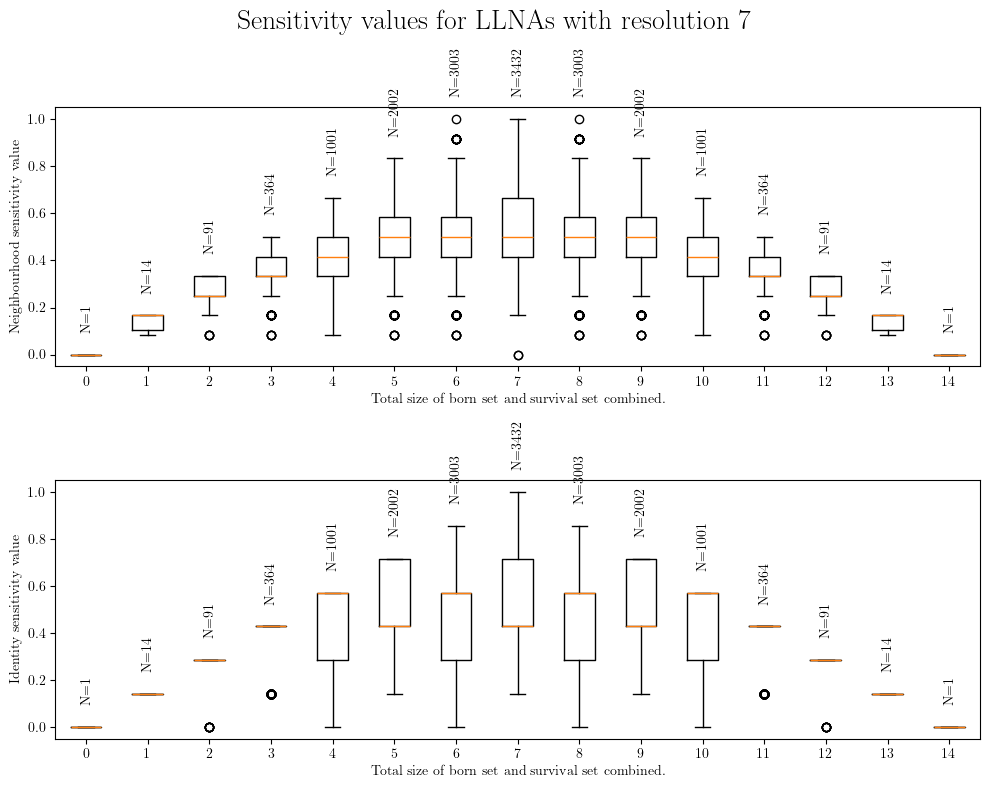

In [15]:
fig, axs = plt.subplots(2,1,figsize=(10,8), sharex=False)
axs[0].boxplot(j_values_per_total_size, tick_labels=total_sizes)
axs[1].boxplot(j_values_cn_per_total_size, tick_labels=total_sizes)
for ax in axs:
    ax.set_xlabel(f"Total size of born set and survival set combined.")
axs[0].set_ylabel("Neighbourhood sensitivity value")
axs[1].set_ylabel("Identity sensitivity value")

# Annotate with the number of data points
for i, (dataset1, dataset2) in enumerate(zip(j_values_per_total_size, j_values_cn_per_total_size)):
    n1 = len(dataset1)  # Number of data points
    n2 = len(dataset2)
    axs[0].text(i + 1, max(dataset1) + 0.1, f'N={n1}', ha='center', fontsize=10, rotation=90)
    axs[1].text(i + 1, max(dataset2) + 0.1, f'N={n2}', ha='center', fontsize=10, rotation=90)

fig.suptitle(f"Sensitivity values for LLNAs with resolution {resolution}", size=20)
fig.tight_layout()

In [16]:
# TODO: add a grid with size vs size with colours indicating the average jaggedness.

# Define parameters
resolution = 7
R_set = np.arange(resolution)

B_sizes = range(resolution + 1)
S_sizes = range(resolution + 1)

# Precompute all combinations for given sizes
combinations_by_size = {size: list(itertools.combinations(R_set, size)) for size in range(resolution + 1)}

# Initialize grids for results
j_values_mean_grid = np.zeros((resolution + 1, resolution + 1))
j_values_cn_mean_grid = np.zeros((resolution + 1, resolution + 1))

# Compute mean jaggedness values
for B_size in B_sizes:
    print(f"Working on B_size {B_size}/{resolution}.    ", end='\r')
    B_sets = combinations_by_size[B_size]
    for S_size in S_sizes:
        S_sets = combinations_by_size[S_size]
        # Compute jaggedness values for all combinations
        j_values = [
            nbh_sensitivity(resolution, B_set, S_set)
            for B_set in B_sets for S_set in S_sets
        ]
        j_values_cn = [
            id_sensitivity(resolution, B_set, S_set)
            for B_set in B_sets for S_set in S_sets
        ]
        # Store means in grids
        j_values_mean_grid[B_size, S_size] = np.mean(j_values)
        j_values_cn_mean_grid[B_size, S_size] = np.mean(j_values_cn)


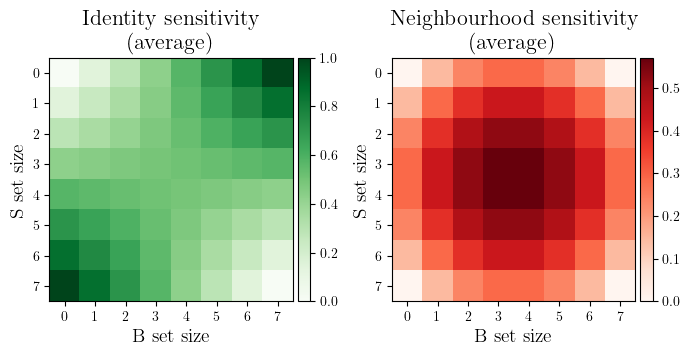

In [17]:
SAVEFIG=False

fig, axs = plt.subplots(1,2,figsize=(7, 4))

im0 = axs[0].imshow(j_values_cn_mean_grid, cmap='Greens')
im1 = axs[1].imshow(j_values_mean_grid, cmap='Reds')

for ax in axs:
    ax.set_xlabel("B set size", size=14)
    ax.set_ylabel("S set size", size=14)
    ax.set_xticks(range(resolution+1))
axs[0].set_title("Identity sensitivity\n(average)", size=16)
axs[1].set_title("Neighbourhood sensitivity\n(average)", size=16)

# Create a colorbar that aligns perfectly
import mpl_toolkits
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Create an axis for the colorbar
divider = make_axes_locatable(axs[0])
cax = divider.append_axes("right", size="5%", pad=0.05)  # Adjust size and padding
cbar = plt.colorbar(im0, cax=cax)  # Use the new axis for the colorbar
# Same for the second one
divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size="5%", pad=0.05)  # Adjust size and padding
cbar = plt.colorbar(im1, cax=cax)  # Use the new axis for the colorbar

fig.tight_layout()

if SAVEFIG:
    # Note: saving as PDF fails to show the hatches
    plt.savefig(f"ID-and-NS-res7.png", dpi=600)

Interestingly, these values seem to convey very different information! Also note that the observed symmetry corresponds with imposed isomorphisms.

The above discussion shows the distribution of the values simply as a result of combinatorics. A complete and useful definition of jaggedness should probably take into account these combinatorial aspects, allowing for some kind of normalisation.

In [18]:
# exhaustive figure for all resolution-3 models
# TODO: add a grid with size vs size with colours indicating the average jaggedness.

# Define parameters
resolution = 3
betas = range(2**resolution)
sigmas = range(2**resolution)

# Initialize grids for results
j_values_mean_grid = np.zeros((2**resolution, 2**resolution))
j_values_cn_mean_grid = np.zeros((2**resolution, 2**resolution))

# Compute mean jaggedness values
for beta in betas:
    print(f"Working on beta {beta}/{2**resolution-1}.    ", end='\r')
    B_set = []
    for k, digit in enumerate(np.base_repr(beta)[::-1]):
        if digit=='1':
            B_set.append(k)
    for sigma in sigmas:
        S_set = []
        for k, digit in enumerate(np.base_repr(sigma)[::-1]):
            if digit=='1':
                S_set.append(k)
        j_value = nbh_sensitivity(resolution, B_set, S_set)
        j_value_cn = id_sensitivity(resolution, B_set, S_set)
        # Store means in grids
        j_values_mean_grid[beta, sigma] = j_value
        j_values_cn_mean_grid[beta, sigma] = j_value_cn

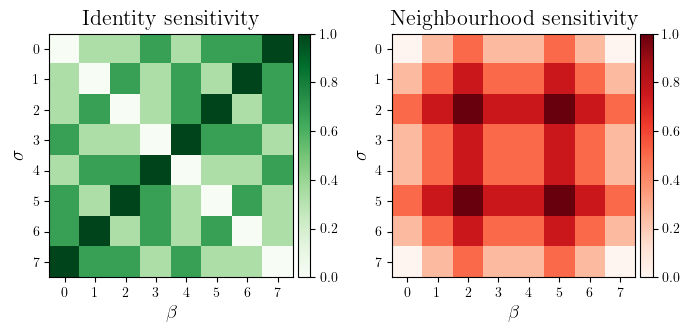

In [19]:
SAVEFIG=False

fig, axs = plt.subplots(1,2,figsize=(7, 4))

im0 = axs[0].imshow(j_values_cn_mean_grid, cmap='Greens')
im1 = axs[1].imshow(j_values_mean_grid, cmap='Reds')

for ax in axs:
    ax.set_xlabel(r"$\beta$", size=14)
    ax.set_ylabel(r"$\sigma$", size=14)
    ax.set_xticks(betas)
axs[0].set_title("Identity sensitivity", size=16)
axs[1].set_title("Neighbourhood sensitivity", size=16)

# Create a colorbar that aligns perfectly
import mpl_toolkits
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Create an axis for the colorbar
divider = make_axes_locatable(axs[0])
cax = divider.append_axes("right", size="5%", pad=0.05)  # Adjust size and padding
cbar = plt.colorbar(im0, cax=cax)  # Use the new axis for the colorbar
# Same for the second one
divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size="5%", pad=0.05)  # Adjust size and padding
cbar = plt.colorbar(im1, cax=cax)  # Use the new axis for the colorbar

fig.tight_layout()

if SAVEFIG:
    # Note: saving as PDF fails to show the hatches
    plt.savefig(f"ID-and-NS-res3.png", dpi=600)

### Comparison with Lyapunov spectrum

Each of the local update rules can be compared to their Lyapunov spectrum. That is a good indicator of how good a measure this is.

First, let us consider the idea that every totalistic ECA can be translated to a LLNA on a regular graph. In particular, such ECAs can be encoded in resolution-3 LLNAs. Note that there are $2^4$ totalistic ECAs, and $2^6$ resolution-3 LLNAs, so this mapping is not bijective.

An ECA is totalistic if the order of the cells does not matter. This means that a binary representation of the ECA should be $b_7 b_6 b_5 b_4 b_3 b_2 b_1 b_0$ with
$$
\begin{align}
\begin{cases}
b_6 = b_5 = b_3, \qquad &\text{(two living cells)}\\
b_4 = b_2 = b_1. \qquad &\text{(one living cells)}
\end{cases}
\end{align}
$$

Actually, there is a bijective map from ECA to LLNA, by demanding that
$$
\begin{align}
\begin{cases}
b_6 = b_3, \qquad &\text{(alive, one neighbour)}\\
b_4 = b_1. \qquad &\text{(dead, one neighbour)}
\end{cases}
\end{align}
$$

This indeed sums to $64$ possibilities.

Now we are especially interested in the ECAs that have a constant Jacobian, meaning that its response to a defect does not depend on the particular state configuration. Here the demand is that the value of the gradient does _not_ depend on the configuration, i.e.
$$
\left(\frac{\partial f}{\partial x_{i-1}}, \frac{\partial f}{\partial x_{i}}, \frac{\partial f}{\partial x_{i+1}}\right) \in \{0,1\}^3,
$$
where
$$
\frac{\partial f}{\partial x_{i}} = f(x_{i-1}, x_i, x_{i+1}) \oplus f(x_{i-1}, \bar{x}_i, x_{i+1}).
$$
Here $f$ is the local update rule of the ECA, and the $\bar{x}$ denotes the binary complement ($\bar{x} = 1-x$). This means that we must demand that
$$
\begin{align}
\begin{cases}
f(1, 1, 1) \oplus f(1, 0, 1) = k \in \{0, 1\}, \\
f(1, 1, 0) \oplus f(1, 0, 0) = k, \\
f(0, 1, 1) \oplus f(0, 0, 1) = k, \\
f(0, 1, 0) \oplus f(0, 0, 0) = k.
\end{cases}
\end{align}
$$
In binary notation, this becomes
$$
\begin{align}
\begin{cases}
b_7 \oplus b_5 = k \in \{0, 1\}, \\
b_6 \oplus b_4 = k, \\
b_3 \oplus b_1 = k, \\
b_2 \oplus b_0 = k.
\end{cases}
\end{align}
$$
This in turn translates to the following demand:
$$
\begin{align}
[ (b_7 = b_5) \land (b_6 = b_4) \land (b_3 = b_1) \land (b_2 = b_0) ] \lor [ (b_7 = \bar{b}_5) \land (b_6 = \bar{b}_4) \land (b_3 = \bar{b}_1) \land (b_2 = \bar{b}_0) ].
\end{align}
$$

TODO: this is not correct! I'm missing something; I'm counting twice as many as I need.

In [48]:
def eca_to_llna(eca:int):
    if not eca_is_llna(eca):
        raise Exception(f"Rule {eca} cannot be translated to an LLNA.")
    eca_binary_reverse = base_repr_padded(eca, 8)[::-1]
    B_set = []
    S_set = []
    for interval, dead_bit in enumerate([0, 1, 5]):
        if eca_binary_reverse[dead_bit]=='1':
            B_set.append(interval)
    for interval, live_bit in enumerate([2, 3, 7]):
        if eca_binary_reverse[live_bit]=='1':
            S_set.append(interval)
    return B_set, S_set

def eca_is_totalistic(eca:int):
    # make list of all totalistic ECAs
    totalistic_ecas = []
    for b7 in [0,1]:
        for b6 in [0,1]:
            b5 = b6; b3 = b6
            for b4 in [0,1]:
                b2 = b4; b1=b4
                for b0 in [0,1]:
                    tot_eca = 2**7*b7 + 2**6*b6 + 2**5*b5 + 2**4*b4 + 2**3*b3 + 2**2*b2 + 2**1*b1 + 2**0*b0
                    totalistic_ecas.append(tot_eca)
    if eca in totalistic_ecas:
        return True
    return False

def eca_is_llna(eca:int):
    # make list of all totalistic ECAs
    llna_ecas = []
    for b7 in [0,1]:
        for b6 in [0,1]:
            b3 = b6
            for b5 in [0,1]:
                for b4 in [0,1]:
                    b1=b4
                    for b2 in [0,1]:
                        for b0 in [0,1]:
                            llna_eca = 2**7*b7 + 2**6*b6 + 2**5*b5 + 2**4*b4 + 2**3*b3 + 2**2*b2 + 2**1*b1 + 2**0*b0
                            llna_ecas.append(llna_eca)
    if eca in llna_ecas:
        return True
    return False

def eca_is_constantJ(eca:int):
    # make list of all constant-Jacobian ECAs
    constantJ_ecas = []
    for b7 in [0,1]:
        b5 = b7
        for b6 in [0,1]:
            b4 = b6
            for b3 in [0,1]:
                b1 = b3
                for b2 in [0,1]:
                    b0 = b2
                    constantJ_eca = 2**7*b7 + 2**6*b6 + 2**5*b5 + 2**4*b4 + 2**3*b3 + 2**2*b2 + 2**1*b1 + 2**0*b0
                    constantJ_ecas.append(constantJ_eca)
    for b7 in [0,1]:
        b5 = 1-b7
        for b6 in [0,1]:
            b4 = 1-b6
            for b3 in [0,1]:
                b1 = 1-b3
                for b2 in [0,1]:
                    b0 = 1-b2
                    constantJ_eca = 2**7*b7 + 2**6*b6 + 2**5*b5 + 2**4*b4 + 2**3*b3 + 2**2*b2 + 2**1*b1 + 2**0*b0
                    constantJ_ecas.append(constantJ_eca)
    if eca in constantJ_ecas:
        return True
    return False

count=0
for eca in range(256):
    if eca_is_constantJ(eca):
        print(eca)

0
5
10
15
51
54
57
60
80
85
90
95
99
102
105
108
147
150
153
156
160
165
170
175
195
198
201
204
240
245
250
255


In [27]:
# get singular values from analytical expression
# TODO: copy this to the backend

import warnings
from src.analysis import jacobian_ECA

def singular_values_from_rule(rule, N):
    # exceptions
    all_constantJ_rules = [0, 255, 85, 170, 51, 204, 102, 153, 15, 240, 90, 165, 60, 195, 105, 150]
    if rule not in all_constantJ_rules: raise Exception(f"Rule {rule} does not have a constant Jacobian.")
    # find constants
    J = jacobian_ECA(rule, np.zeros(N), return_next=False)
    triplet = J[1,0:3]
    c0 = triplet[1]
    c1 = triplet[0]
    cN_1 = triplet[2]
    cc0 = c0**2 + c1**2 + cN_1**2
    cc1 = c0*c1 + cN_1*c0
    cc2 = cN_1*c1
    # calculate singular values
    singular_values = []
    for k in range(N):
        # note: for some reason this loop takes a long time
        arg = cc0 + 2*cc1*np.cos(2*k*np.pi/N) + 2*cc2*np.cos(4*k*np.pi/N)
        # numerical errors occur sometimes already here!
        if arg < 0: warnings.warn(f"Numerical issue: a square root argument is negative for rule {rule}: {arg}.", UserWarning)
        singular_value = np.sqrt(arg)
        singular_values.append(singular_value)
    return np.array(singular_values)

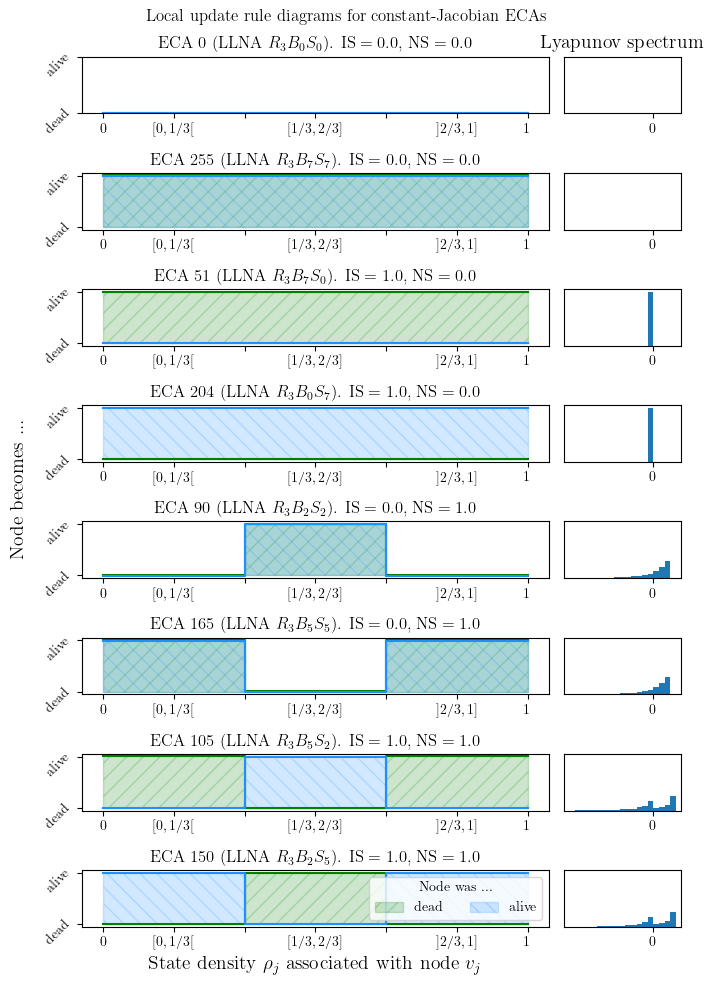

In [23]:
SAVEFIG=False

# from Vichniac
all_constantJ_rules = [0, 255, 85, 170, 51, 204, 102, 153, 15, 240, 90, 165, 60, 195, 105, 150]

# take all constant-Jacobian ECAs that can be represented as an LLNA
constantJ_llnas = []
for eca in all_constantJ_rules:
    if eca_is_llna(eca):
        constantJ_llnas.append(eca)

# find singular values analytically
N = 2*3*4*20+1
bins = np.linspace(-4, np.log(3), 20)

fig, axs = plt.subplots(len(constantJ_llnas), 2, figsize=(7, 10), width_ratios=[4,1])

resolution=3
for ax, eca in zip(axs, constantJ_llnas):
    ax_left, ax_right = ax
    # make LLNA diagram
    born_if, survive_if = eca_to_llna(eca)
    model = LLNA(resolution, x=born_if, y=survive_if, iso=True)
    model.diagram(ax=ax_left)
    IS = id_sensitivity(resolution, born_if, survive_if)
    NS = nbh_sensitivity(resolution, born_if, survive_if)
    ax_left.set_title(fr"ECA {eca} (LLNA {model.__str__(latex=True)}). $\text{{IS}}={IS}$, $\text{{NS}}={NS}$")
    ax_left.set_ylabel(None)
    # make Lyapunov spectrum. Takes a little while to calculate
    singular_values = singular_values_from_rule(eca, N)
    # eliminate singular values of zero (and negative ones from numerical problems)
    non_zero_singular_values = singular_values[singular_values>0]
    perc_strictly_pos = round(len(non_zero_singular_values) / N * 100)
    lyapunov_values = np.log(non_zero_singular_values)
    ax_right.hist(lyapunov_values, bins=bins)
for ax in axs[:-1]:
    ax_left, ax_right = ax
    ax_left.set_xlabel(None)
    ax_left.get_legend().remove()
    ax_right.set_ylim([0,N*1.05])
    ax_right.set_yticks([])
    ax_right.set_xticks([0])

axs[0,1].set_title(f"Lyapunov spectrum", size=14)
axs[-1,0].set_xlabel(fr"State density $\rho_j$ associated with node $v_j$", size=14)
axs[-1,1].set_ylim([0,N*1.05])
axs[-1,1].set_yticks([])
axs[-1,1].set_xticks([0])

# clean and save
fig.supylabel("Node becomes ...", size=14)
fig.suptitle("Local update rule diagrams for constant-Jacobian ECAs")
fig.tight_layout()
if SAVEFIG:
    # Note: saving as PDF fails to show the hatches
    plt.savefig(f"update-rule-diagram_rule{model.__str__()}.png", dpi=600)

0
255
51
204
90
165
105
150
